# Activity 3 — Used Car Price Prediction

**Goal:** Predict used-car prices from `Kms_Driven`, `Year`, `Engine` and `Horsepower`, and compare **Linear Regression** with **Polynomial Regression** (degree 2, 3, 4).

**File required:** `car_price_prediction.csv` (same folder as this notebook)

### How it works
Polynomial regression adds powers of the features (x², x³, x⁴ …) and then fits an ordinary linear regression on them. This lets the model follow **curved** relationships. A higher degree fits the training data better but can **overfit**, so we judge every model on the test set.

## Setup — imports and loading the dataset

If your CSV uses different column names (for example `km_driven`, `year`, `max_power`, `selling_price`), only edit the `COLS` dictionary below. Left side = name used in this notebook, right side = name in your file.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("car_price_prediction.csv")
print(df.columns.tolist())

COLS = {
    "Kms_Driven": "Kms_Driven",
    "Year":       "Year",
    "Engine":     "Engine",
    "Horsepower": "Horsepower",
    "Price":      "Price",
}
df = df.rename(columns={real: mine for mine, real in COLS.items()})
df.head()

['Car_ID', 'Kms_Driven', 'Year', 'Engine', 'Horsepower', 'Price']


,Car_ID,Kms_Driven,Year,Engine,Horsepower,Price
0,1,36705,2018,1560,94,684000
1,2,93291,2015,1350,85,554000
2,3,320000,2005,1540,95,148000
3,4,57376,2019,1650,125,936000
4,5,42133,2021,1470,129,957000


## Task 1 — Choose features and clean the data

Features: `Kms_Driven`, `Year`, `Engine`, `Horsepower`. Target: `Price`.

The cleaning step removes text units (like "1197 CC") if they exist and drops incomplete rows.

In [2]:
features = ["Kms_Driven", "Year", "Engine", "Horsepower"]
data = df[features + ["Price"]].copy()

for col in features + ["Price"]:
    if not pd.api.types.is_numeric_dtype(data[col]):
        data[col] = data[col].astype(str).str.extract(r"([\d\.]+)")[0].astype(float)

print("Missing values:")
print(data.isna().sum())

data = data.dropna().reset_index(drop=True)
print("\nShape after cleaning:", data.shape)
data.describe()

Missing values:
Kms_Driven    0
Year          0
Engine        0
Horsepower    0
Price         0
dtype: int64

Shape after cleaning: (1000, 5)


,Kms_Driven,Year,Engine,Horsepower,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,108235.926000,2014.147000,1577.010000,116.081000,7.944940e+05
std,73866.373026,5.581984,428.058166,37.051387,4.055962e+05
min,500.000000,2005.000000,800.000000,55.000000,6.000000e+04
25%,46465.250000,2009.000000,1250.000000,89.000000,5.217500e+05
50%,98266.000000,2014.000000,1575.000000,117.000000,7.365000e+05
75%,154564.250000,2019.000000,1890.000000,142.000000,1.025250e+06
max,320000.000000,2023.000000,2770.000000,251.000000,3.171000e+06


## Task 2 — Split and scale the data

Scaling matters a lot for polynomial regression: without it, `Kms_Driven⁴` would be astronomically larger than `Horsepower²`.

In [3]:
X = data[features]
y = data["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)

Train: (800, 4)  Test: (200, 4)


## Task 3 — Apply Linear Regression and record performance

We keep a `results` list so every model's RMSE and R² can be compared later.

In [4]:
results = []

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
pred = linear_model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
results.append({"Model": "Linear Regression", "Degree": 1, "RMSE": rmse, "R2": r2})

print(f"Linear Regression -> RMSE: {rmse:.2f}, R²: {r2:.4f}")

Linear Regression -> RMSE: 101299.39, R²: 0.9352


## Task 4 — Apply Polynomial Regression (degree = 2, 3, 4)

A pipeline first creates the polynomial features and then fits a linear regression on them. Train and test scores are both recorded — a big gap between them is a sign of overfitting.

In [5]:
for degree in [2, 3, 4]:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    poly_model.fit(X_train_scaled, y_train)

    pred = poly_model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    r2_train = r2_score(y_train, poly_model.predict(X_train_scaled))

    results.append({"Model": f"Polynomial (degree {degree})", "Degree": degree,
                    "RMSE": rmse, "R2": r2, "R2_train": r2_train})
    print(f"Degree {degree} -> RMSE: {rmse:.2f}, Test R²: {r2:.4f}, Train R²: {r2_train:.4f}")

Degree 2 -> RMSE: 64638.26, Test R²: 0.9736, Train R²: 0.9784
Degree 3 -> RMSE: 67642.63, Test R²: 0.9711, Train R²: 0.9801
Degree 4 -> RMSE: 67110.17, Test R²: 0.9715, Train R²: 0.9816


## Task 5 — Compare the results

In [6]:
results_df = pd.DataFrame(results)
display(results_df.round(4))

best = results_df.loc[results_df["R2"].idxmax()]
print(f"Best model on the test set: {best['Model']} (R² = {best['R2']:.4f}, RMSE = {best['RMSE']:.2f})")

,Model,Degree,RMSE,R2,R2_train
0,Linear Regression,1,101299.3863,0.9352,NaN
1,Polynomial (degree 2),2,64638.2588,0.9736,0.9784
2,Polynomial (degree 3),3,67642.6298,0.9711,0.9801
3,Polynomial (degree 4),4,67110.1698,0.9715,0.9816


Best model on the test set: Polynomial (degree 2) (R² = 0.9736, RMSE = 64638.26)


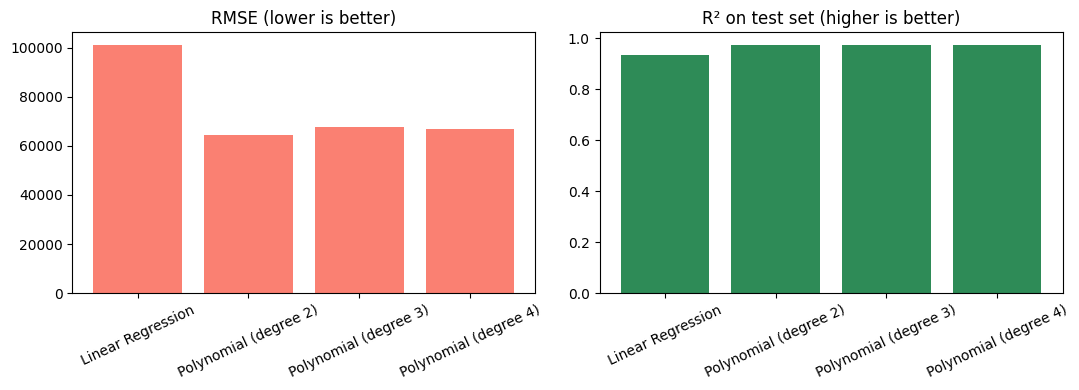

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(results_df["Model"], results_df["RMSE"], color="salmon")
axes[0].set_title("RMSE (lower is better)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(results_df["Model"], results_df["R2"], color="seagreen")
axes[1].set_title("R² on test set (higher is better)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## Task 6 — Plot fitted curves for different polynomial degrees

A plot needs one x-axis, so we show **Price vs Horsepower**. Here a separate model is fitted on Horsepower alone for degree 1 (straight line), 2, 3 and 4, so you can see how the curve bends more as the degree grows.

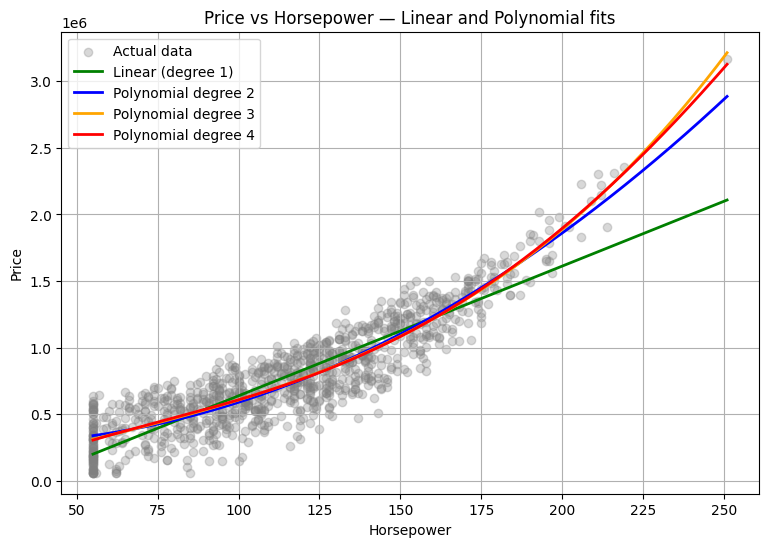

In [8]:
feature = "Horsepower"

hp_scaler = StandardScaler()
hp_scaled = hp_scaler.fit_transform(data[[feature]])

x_line = np.linspace(data[feature].min(), data[feature].max(), 300).reshape(-1, 1)
x_line_scaled = hp_scaler.transform(pd.DataFrame(x_line, columns=[feature]))

plt.figure(figsize=(9, 6))
plt.scatter(data[feature], data["Price"], alpha=0.3, color="gray", label="Actual data")

styles = {1: ("green", "Linear (degree 1)"), 2: ("blue", "Polynomial degree 2"),
          3: ("orange", "Polynomial degree 3"), 4: ("red", "Polynomial degree 4")}

for degree, (color, label) in styles.items():
    curve_model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                                LinearRegression())
    curve_model.fit(hp_scaled, data["Price"])
    plt.plot(x_line, curve_model.predict(x_line_scaled), color=color, linewidth=2, label=label)

plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.title("Price vs Horsepower — Linear and Polynomial fits")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation
- The straight line cannot follow the curve in the data, so it has the highest error.
- Degree 2 usually gives the biggest improvement. Degrees 3 and 4 add only a small gain (or none) on the test set.
- If the **train** R² keeps rising while the **test** R² stops improving or falls, the higher-degree model is **overfitting**, and the simplest model that fits well (often degree 2) is the better choice.